In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'Warehouse'))

In [2]:
from Inventory_Builder import Inventory_Builder, InventoryConfig
from Storage_Primitive import Storage_Type

## Parameters

- `num_skus` — number of cartons to generate
- `handling_splits` — probability weights for `['conveyable', 'non-conveyable']`
- `category_splits` — probability weights for `['food', 'clothing', 'electronic', 'furniture', 'seasonal', 'chemical']`

In [3]:
_st = Storage_Type()
print('Handling types :', _st.handling_storage_types)
print('Category types :', _st.category_storage_types)

Handling types : ['conveyable', 'non-conveyable']
Category types : ['food', 'clothing', 'electronic', 'furniture', 'seasonal', 'chemical']


In [4]:
config = InventoryConfig(
    num_skus=200,
    handling_splits=[0.7, 0.3],
    category_splits=[0.2, 0.2, 0.2, 0.2, 0.1, 0.1],
)

## Build

In [5]:
inventory = Inventory_Builder().from_config(config).build()
print(f'SKUs generated: {len(inventory.cartons)}')

SKUs generated: 200


## Storage Type Distribution

In [6]:
import pandas as pd

rows = [{
    'sku'     : c.sku,
    'handling': c.storage_type[0],
    'category': c.storage_type[1],
    'length'  : c.length,
    'width'   : c.width,
    'height'  : c.height,
    'weight'  : c.weight,
    'volume'  : c.volume(),
    'demand_rate': round(c.demand.rate, 2),
} for c in inventory.cartons]

df = pd.DataFrame(rows).set_index('sku')
df.head(10)

,handling,category,length,width,height,weight,volume,demand_rate
sku,,,,,,,,
1,conveyable,chemical,37,46,41,5,69782,6.13
2,non-conveyable,chemical,6,42,45,5,11340,9.68
3,conveyable,chemical,48,15,20,5,14400,5.35
4,conveyable,clothing,38,27,39,5,40014,18.00
5,non-conveyable,furniture,23,31,41,5,29233,10.30
6,conveyable,clothing,44,46,37,5,74888,11.68
7,conveyable,furniture,18,43,46,5,35604,4.74
8,conveyable,seasonal,15,43,19,5,12255,19.14
9,conveyable,chemical,7,47,24,5,7896,16.86


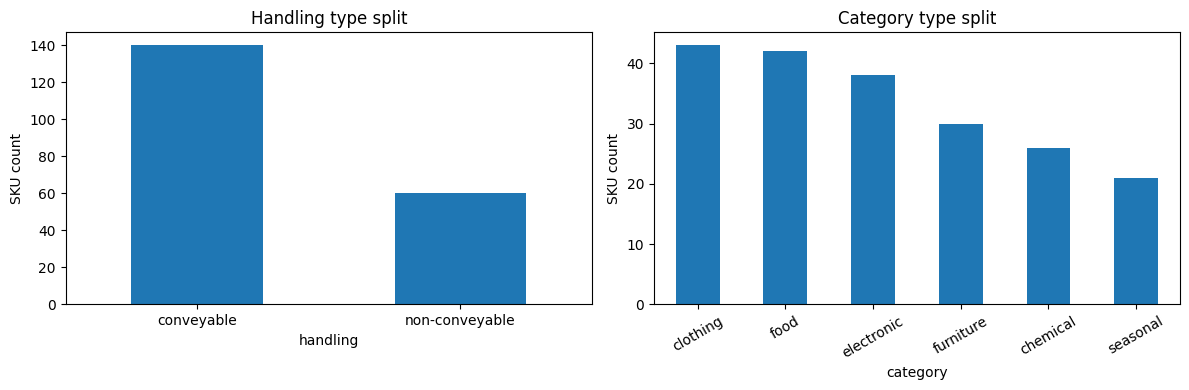

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['handling'].value_counts().plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Handling type split')
axes[0].set_ylabel('SKU count')

df['category'].value_counts().plot(kind='bar', ax=axes[1], rot=30)
axes[1].set_title('Category type split')
axes[1].set_ylabel('SKU count')

plt.tight_layout()
plt.show()

## Dimension Distributions

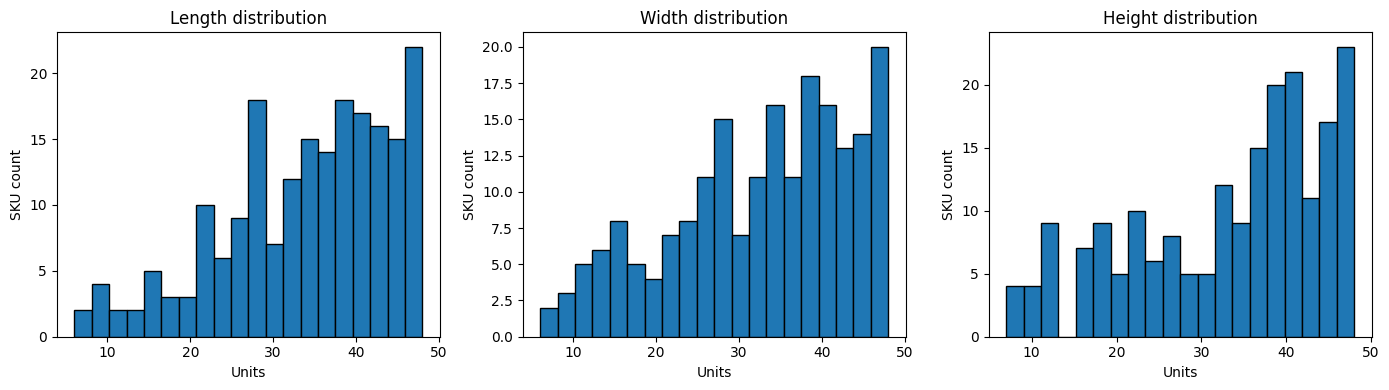

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['length', 'width', 'height']):
    ax.hist(df[col], bins=20, edgecolor='black')
    ax.set_title(f'{col.capitalize()} distribution')
    ax.set_xlabel('Units')
    ax.set_ylabel('SKU count')

plt.tight_layout()
plt.show()

## Demand Rate Distribution

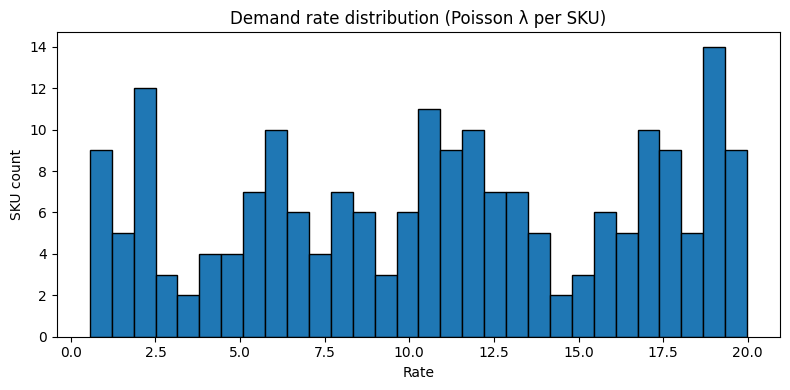

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['demand_rate'], bins=30, edgecolor='black')
ax.set_title('Demand rate distribution (Poisson λ per SKU)')
ax.set_xlabel('Rate')
ax.set_ylabel('SKU count')
plt.tight_layout()
plt.show()

## Simulated Pick Quantities
Sample one pick quantity per SKU and inspect the resulting distribution.

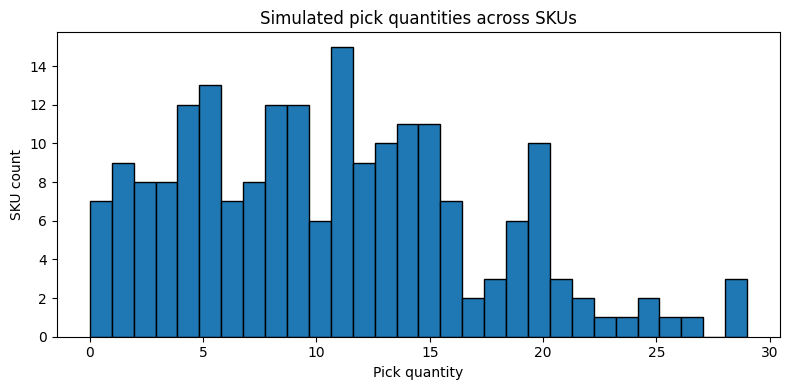

count    200.000000
mean      10.520000
std        6.722766
min        0.000000
25%        5.000000
50%       10.000000
75%       15.000000
max       29.000000
Name: sampled_picks, dtype: float64

In [10]:
df['sampled_picks'] = [c.demand.sample() for c in inventory.cartons]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['sampled_picks'], bins=30, edgecolor='black')
ax.set_title('Simulated pick quantities across SKUs')
ax.set_xlabel('Pick quantity')
ax.set_ylabel('SKU count')
plt.tight_layout()
plt.show()

df['sampled_picks'].describe()